# CAVAanalytics: country-scale climate analysis

This practical follows one question: **How could extreme heat change in Kenya?**

We will load a multi-model dataset, examine observations and model biases, calculate future indicators, map the climate change signal and export a raster.

## 1. Start the R kernel

Open this notebook with **R (CAVA)**. The remote-data cell is the slowest step and requires internet access.

In [6]:
library(CAVAanalytics)
library(ggplot2)
library(patchwork)

packageVersion("CAVAanalytics")

getwd()


CAVAanalytics v4.0.7



[1] ‘4.0.7’

[1] "/Users/riccardo/Library/CloudStorage/Dropbox/RIKI/FAO/presentations/trainings/CAVAtraining/HQ/day3"

## Load data

`load_data()` selects Kenya, resolves the remote files, streams the required grid cells and harmonizes units and time.

In [7]:

cache_file <- file.path("data", "kenya_tasmax_1991_2000_2041_2050.rds")

if (file.exists(cache_file)) {
  kenya_tasmax <- readRDS(cache_file)
} else {
  # This takes about 10 minutes
  kenya_tasmax <- load_data(
    path.to.data = "CORDEX-CORE-BC",
    path.to.obs = "ERA5",
    country = "Kenya",
    variable = "tasmax",
    years.hist = 1980:2005,
    years.obs = 1990:2024,
    years.proj = 2030:2059,
    domain = "AFR-22"
  )
  saveRDS(kenya_tasmax, cache_file)
}

## 4. Inspect the loaded object

In [ ]:
class(kenya_tasmax)
names(attributes(kenya_tasmax))
colnames(kenya_tasmax[[1]])
kenya_tasmax[[1]]$experiment

[1] "CAVAanalytics_list"

[1] "class"      "components"

[1] "experiment"  "models_mbrs" "obs"

[1] "historical" "rcp26"      "rcp85"

## 5. Historical climate and a threshold indicator

First map the mean observed maximum temperature. Then count the annual number of days above 35 °C by season.

→ observations, season 1-2-3-4-5-6-7-8-9-10-11-12. Calculation of mean tasmax

ℹ Performing calculations

✔ Performing calculations [3.4s]



ℹ Plotting

The rnaturalearthhires package needs to be installed.
Installing the rnaturalearthhires package.
 

→ Package library at /Users/riccardo/.local/share/mamba/envs/cava-training/lib/R/library.

→ Will install 1 package.

→ The package (0 B) is cached.

+ rnaturalearthhires   1.0.0.9000 👷🏻‍♀️🔧 (GitHub: e4736f6)

ℹ No downloads are needed, 1 pkg is cached

✔ Installed rnaturalearthhires 1.0.0.9000 (github::ropensci/rnaturalearthhires@e4736f6) (37ms)

✔ 1 pkg: added 1 [4.3s]

→ Visualizing observational dataset

ℹ Plotting
!  Argument ensemble and stat are ignored

ℹ Plotting
✔ Plotting [4.5s]





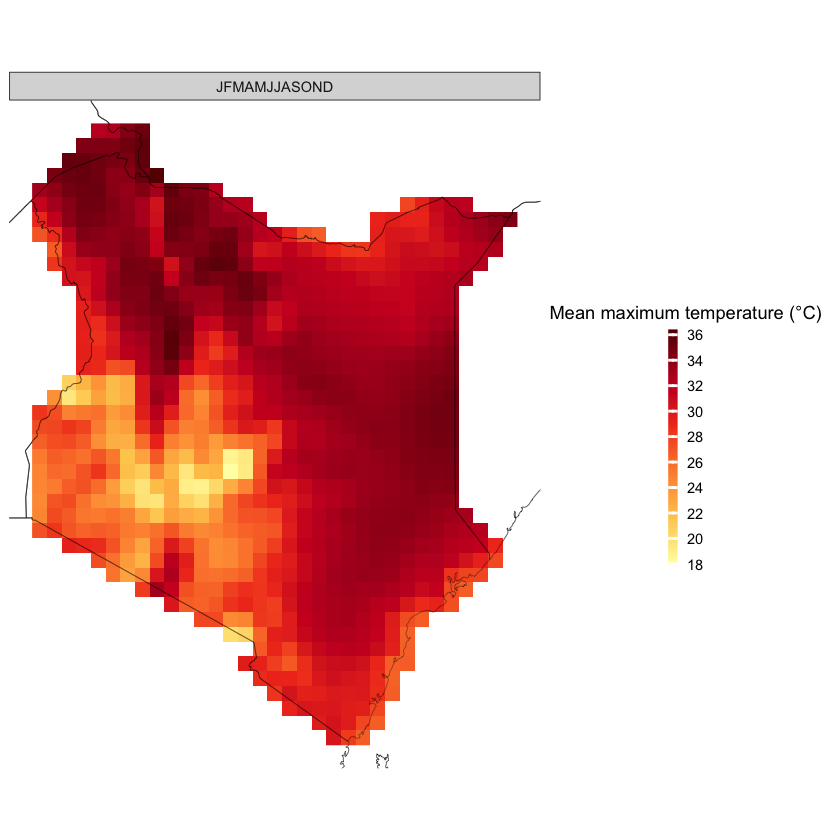

In [10]:
obs_mean <- observations(
  kenya_tasmax,
  season = list(1:12)
)

plotting(
  obs_mean,
  plot_titles = "Mean maximum temperature (°C)",
  palette = IPCC_palette(type = "tmp", divergent = FALSE)
)

→ observations, season 1-2-3. Calculation of number of days with tasmax above
threshold of 35

ℹ Performing calculations

✔ Performing calculations s]



→ observations, season 4-5-6. Calculation of number of days with tasmax above
threshold of 35

ℹ Performing calculations

✔ Performing calculations s]



→ observations, season 7-8-9. Calculation of number of days with tasmax above
threshold of 35

ℹ Performing calculations

✔ Performing calculations s]



→ observations, season 10-11-12. Calculation of number of days with tasmax
above threshold of 35

ℹ Performing calculations

✔ Performing calculations s]



ℹ Plotting

→ Visualizing observational dataset

ℹ Plotting
!  Argument ensemble and stat are ignored

ℹ Plotting
✔ Plotting s]





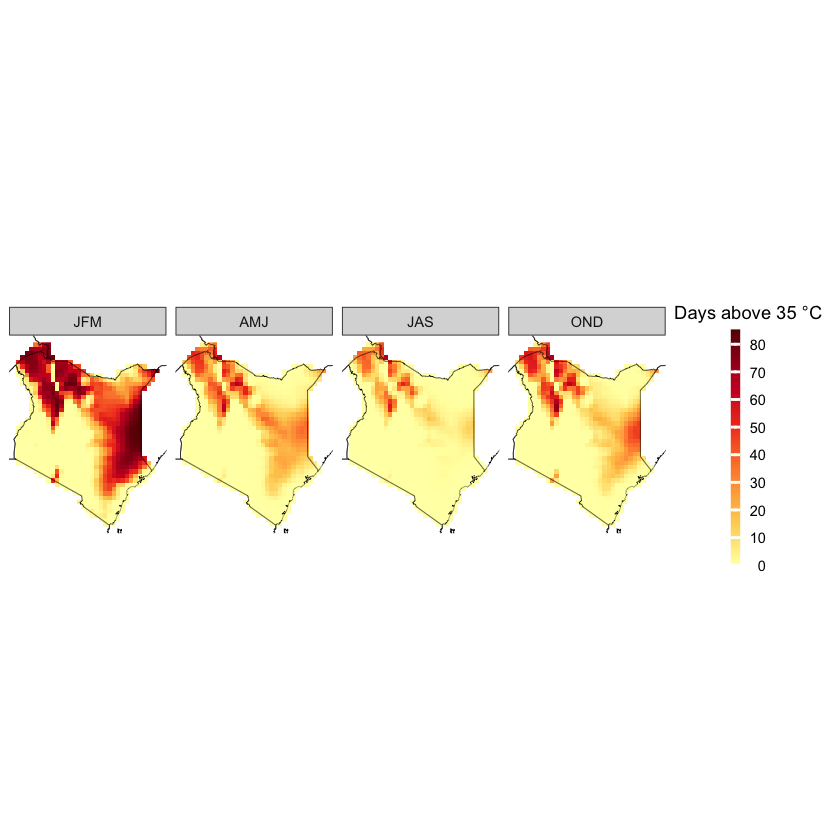

In [11]:
obs_hot_days <- observations(
  kenya_tasmax,
  season = list(1:3, 4:6, 7:9, 10:12),
  uppert = 35
)

plotting(
  obs_hot_days,
  plot_titles = "Days above 35 °C",
  palette = IPCC_palette(type = "tmp", divergent = FALSE)
)

## 6. Model biases

Compare historical model simulations with ERA5. These data already received bias correction, so the function evaluates the remaining bias without applying another correction.

In [ ]:
heat_bias <- model_biases(
  kenya_tasmax,
  season = list(1:12),
  uppert = 35,
  bias.correction = FALSE
)

plotting(
  heat_bias,
  ensemble = TRUE,
  plot_titles = "Bias in days above 35 °C",
  palette = IPCC_palette(type = "tmp", divergent = TRUE)
)

## 7. Future projections

`projections()` can return the ensemble mean, ensemble spread, individual models and annual time series.

In [ ]:
library(patchwork)

future_hot_days <- projections(
  kenya_tasmax,
  season = list(1:3, 4:6, 7:9, 10:12),
  uppert = 35,
  bias.correction = FALSE
)

p_mean <- plotting(
  future_hot_days,
  ensemble = TRUE,
  plot_titles = "Projected days above 35 °C",
  palette = IPCC_palette(type = "tmp", divergent = FALSE)
)

p_mean / p_spread

In [ ]:
plotting(
  future_hot_days,
  ensemble = TRUE,
  temporal = TRUE,
  plot_titles = "Annual days above 35 °C",
  palette = c("#0072B2", "#D55E00")
)

## 8. Consecutive-day indicators

The same analysis functions can calculate the longest hot spell or the number of heat waves.

In [ ]:
longest_hot_spell <- projections(
  kenya_tasmax,
  season = list(1:12),
  uppert = 35,
  consecutive = TRUE,
  duration = "max",
  bias.correction = FALSE
)

plotting(
  longest_hot_spell,
  ensemble = TRUE,
  plot_titles = "Longest spell above 35 °C",
  palette = IPCC_palette(type = "tmp", divergent = FALSE)
)

In [ ]:
heatwave_frequency <- projections(
  kenya_tasmax,
  season = list(1:12),
  uppert = 35,
  consecutive = TRUE,
  duration = 3,
  frequency = TRUE,
  bias.correction = FALSE
)

plotting(
  heatwave_frequency,
  ensemble = TRUE,
  plot_titles = "Heat waves per year",
  palette = IPCC_palette(type = "tmp", divergent = FALSE)
)

## 9. Climate change signal and model agreement

Compare the future and historical periods. Stippling follows the package convention for insufficient agreement on the sign of change.

In [ ]:
heat_change <- climate_change_signal(
  kenya_tasmax,
  season = list(1:3, 4:6, 7:9, 10:12),
  uppert = 35,
  bias.correction = FALSE
)

plotting(
  heat_change,
  ensemble = TRUE,
  plot_titles = "Change in days above 35 °C",
  palette = IPCC_palette(type = "tmp", divergent = TRUE),
  point_size = 0.08
)

In [ ]:
plotting(
  heat_change,
  ensemble = TRUE,
  temporal = TRUE,
  plot_titles = "Annual change in hot days",
  palette = c("#0072B2", "#D55E00")
)

## 10. Export the analytical result

The export writes ensemble mean and standard-deviation GeoTIFFs to `outputs/`.

In [ ]:
extract_raster(
  heat_change,
  file.extension = "kenya_heat_change.tif",
  ensemble = TRUE,
  path = "outputs/"
)

list.files("outputs", pattern = "\\.tif$", full.names = TRUE)

## Optional extensions

- Repeat the workflow with `variable = "pr"` and `aggr.m = "sum"`.
- Use `percentage = TRUE` in `climate_change_signal()` for relative precipitation change.
- Use `load_data_and_projections()` or `load_data_and_climate_change_signal()` for large regions processed in spatial chunks.
- Use a custom area with `country = NULL`, `xlim` and `ylim`.

Documentation: [CAVAanalytics introduction](https://un-fao.github.io/CAVAanalytics/articles/Introduction.html) and [advanced indicators](https://un-fao.github.io/CAVAanalytics/articles/more_advanced.html).

## Takeaway

CAVAanalytics connects remote climate data to country-scale indicators, ensemble interpretation, maps and GIS-ready outputs in one reproducible R workflow.